In [1]:
import warnings
import os
import pickle

import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns
import multiprocessing   as mp


from datetime                  import datetime
from IPython.display           import display, HTML
from sklearn.model_selection   import train_test_split
from catboost                  import CatBoostClassifier
from sklearn.metrics           import (
                                            precision_score,
                                            recall_score,
                                            f1_score,
                                            roc_auc_score,
                                            accuracy_score,
                                            confusion_matrix,
                                            precision_recall_curve,
                                            roc_curve,
                                            auc
                                        )
from libs.estimators import *
warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
display(HTML("<style>.container { width:100% !important; }</style>"))
pd.options.display.float_format = '{:,.3f}'.format
pd.set_option('display.max_columns', None)

In [2]:
path = f'prepared_data/dataset_for_modeling.pickle'

with open(path, 'rb') as f:
    samples = pickle.load(f)

df = samples['df']
info = samples['info']
features = samples['features']
target = samples['target']
cat_features = []

# MODELING

In [3]:
df[cat_features] = df[cat_features].astype('str')

In [4]:
df['datetime'] = pd.to_datetime(df['datetime']).dt.floor('D')
test_start = pd.to_datetime('2025-01-01').tz_localize('UTC')
test_time  = df[df.datetime >= test_start]
build      = df[df.datetime <  test_start]

build, test_sample = train_test_split(
                                    build,
                                    test_size=0.1,
                                    stratify=build['target'],
                                    random_state=42
                                )

train, valid = train_test_split(
                                    build,
                                    test_size=0.2,
                                    stratify=build['target'],
                                    random_state=42 
                                )

In [5]:
test_time.shape, test_sample.shape, train.shape, valid.shape, build.shape

((21115, 34), (3171, 34), (22824, 34), (5707, 34), (28531, 34))

In [6]:
build[target].value_counts()

target
0         14636
1         13895
Name: count, dtype: int64

In [7]:
test_time[target].value_counts()

target
1         10659
0         10456
Name: count, dtype: int64

In [9]:
X_train, y_train = train[features + cat_features], train[target[0]]
X_valid, y_valid = valid[features + cat_features], valid[target[0]]
X_build, y_build = build[features + cat_features], build[target[0]]
X_test_time, y_test_time = test_time[features + cat_features], test_time[target[0]]
X_test_sample, y_test_sample = test_sample[features + cat_features], test_sample[target[0]]

In [10]:
# Создание модели
model = CatBoostClassifier(
    iterations            = 1000,       # количество деревьев
    learning_rate         = 0.1,    # скорость обучения
    max_depth             = 10,              # глубина деревьев
    cat_features          = cat_features,  # категориальные признаки
    verbose               = 10,            # вывод лога каждые 10 итераций
    random_seed           = 32,
    loss_function         = 'Logloss',
    eval_metric           = 'AUC',
    auto_class_weights    = 'Balanced', # вручныую балансы [1,4]
#     class_weights          = [1,2],
    use_best_model        = True,
    early_stopping_rounds = 100
)

# Обучение модели
model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

0:	test: 0.5899014	best: 0.5899014 (0)	total: 280ms	remaining: 4m 39s
10:	test: 0.6299492	best: 0.6309011 (7)	total: 888ms	remaining: 1m 19s
20:	test: 0.6380236	best: 0.6380236 (20)	total: 1.51s	remaining: 1m 10s
30:	test: 0.6442435	best: 0.6442435 (30)	total: 2.09s	remaining: 1m 5s
40:	test: 0.6487311	best: 0.6489848 (38)	total: 2.71s	remaining: 1m 3s
50:	test: 0.6510525	best: 0.6516869 (46)	total: 3.28s	remaining: 1m 1s
60:	test: 0.6501507	best: 0.6516869 (46)	total: 3.91s	remaining: 1m
70:	test: 0.6518980	best: 0.6518980 (70)	total: 4.51s	remaining: 59.1s
80:	test: 0.6560704	best: 0.6563664 (76)	total: 5.12s	remaining: 58.1s
90:	test: 0.6548304	best: 0.6564209 (82)	total: 5.75s	remaining: 57.4s
100:	test: 0.6559158	best: 0.6564209 (82)	total: 6.35s	remaining: 56.5s
110:	test: 0.6577403	best: 0.6577403 (110)	total: 6.98s	remaining: 55.9s
120:	test: 0.6601422	best: 0.6602025 (119)	total: 7.61s	remaining: 55.3s
130:	test: 0.6622725	best: 0.6625725 (126)	total: 8.21s	remaining: 54.4s
14

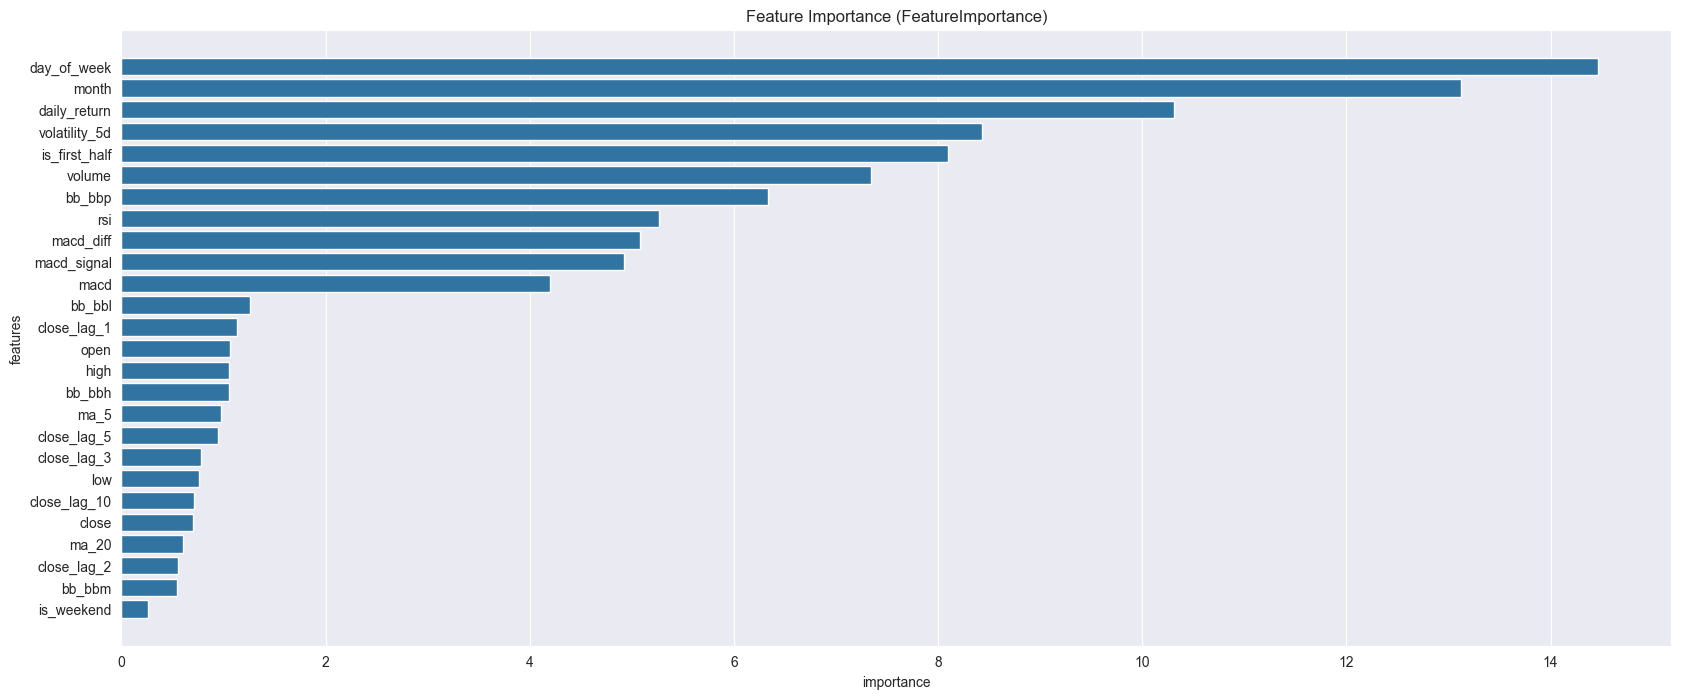

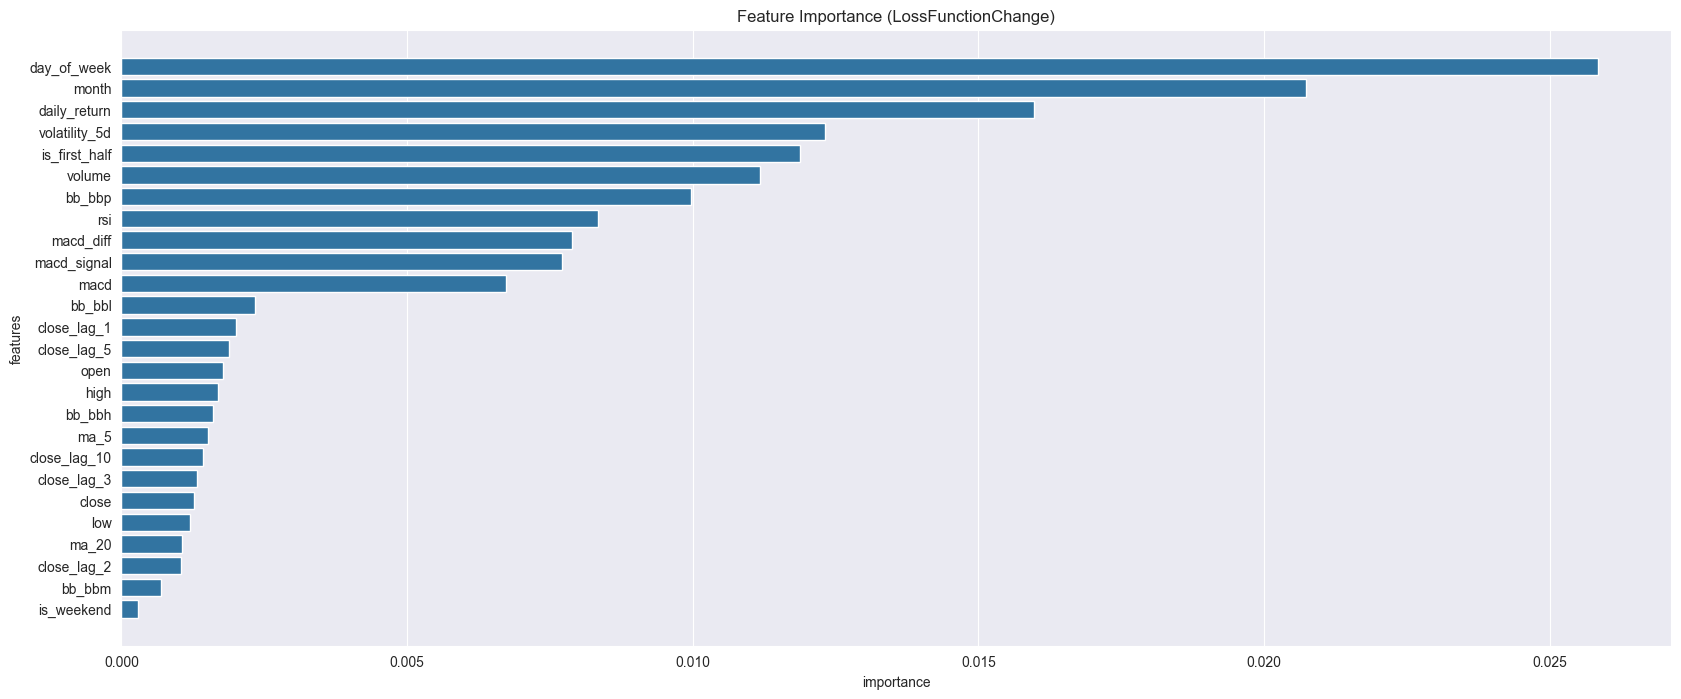

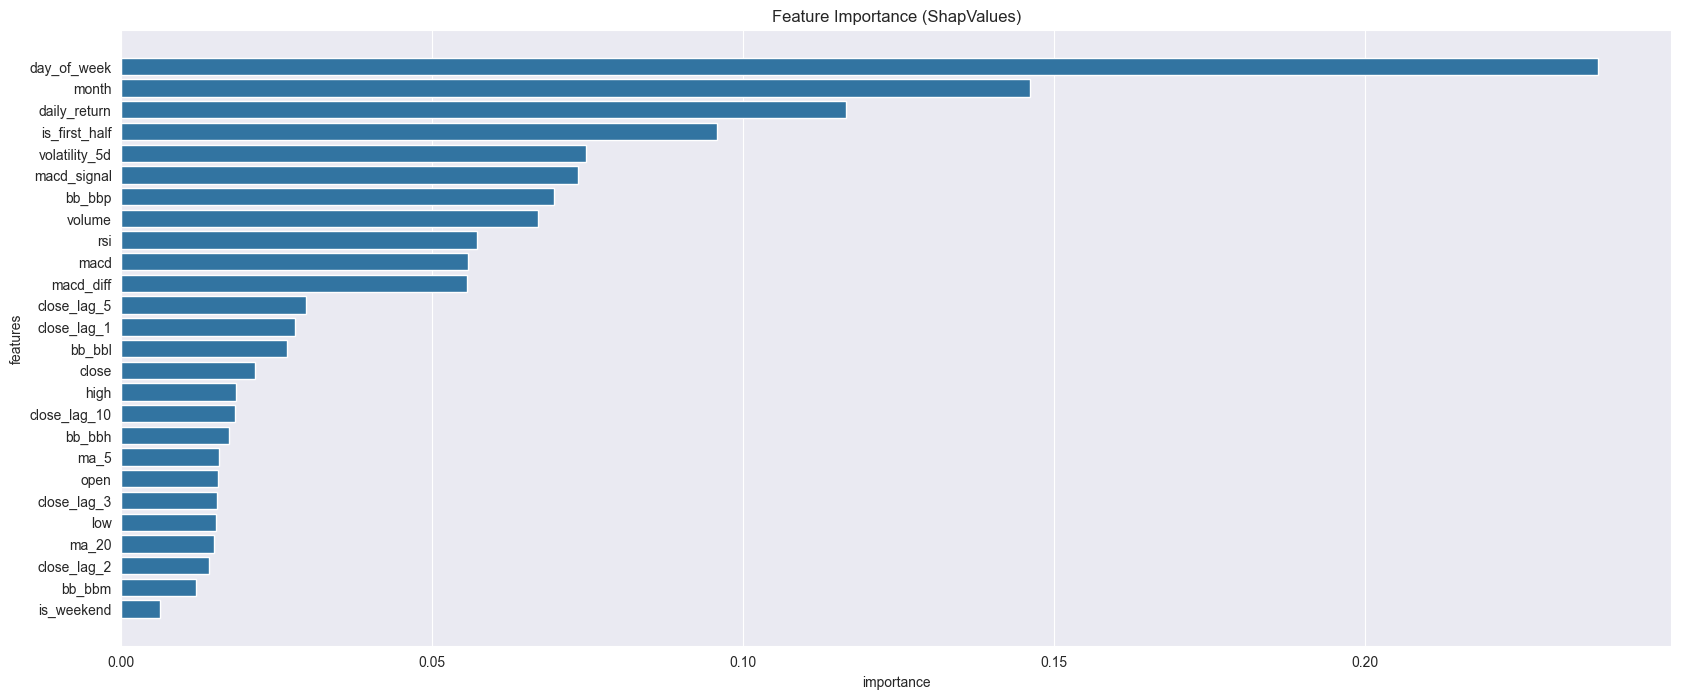

In [11]:
find_feature_importance_catboost(X_train, y_train, cat_features, model, 'FeatureImportance') 
find_feature_importance_catboost(X_train, y_train, cat_features, model, 'LossFunctionChange')
find_feature_importance_catboost(X_train, y_train, cat_features, model, 'ShapValues')

np.float64(0.47)

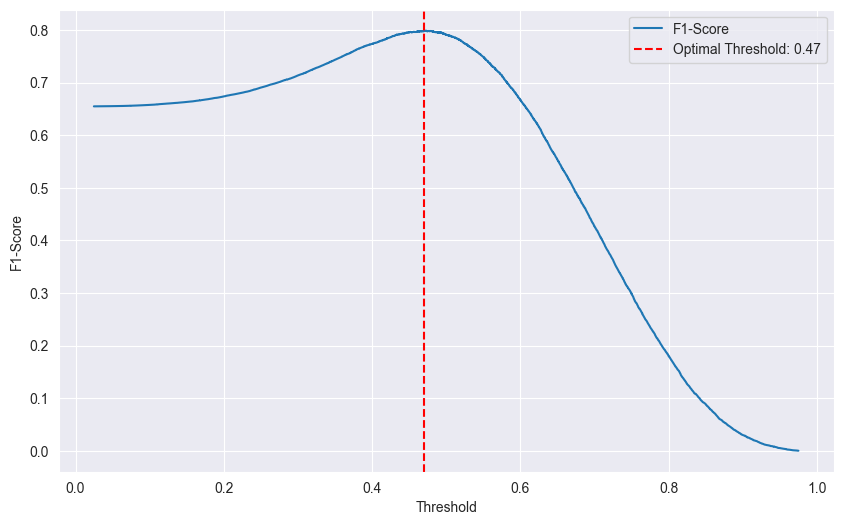

In [12]:
optimal_threshold_f1 = find_best_threshold_prev(X_build, y_build, model)
optimal_threshold_f1

Optimal Threshold: 0.50
TPR at Optimal Threshold: 0.80
TNR at Optimal Threshold: 0.80


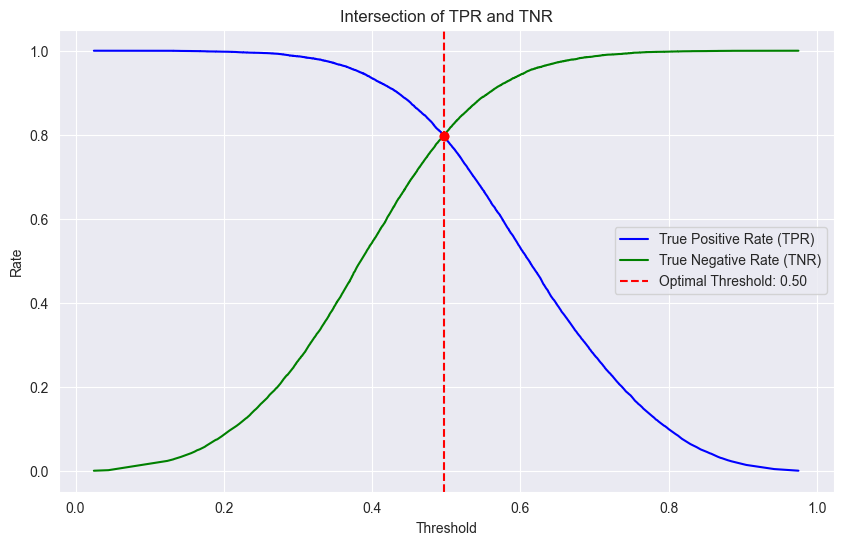

In [13]:
y_pred_proba      = model.predict_proba(X_build)[:, 1] 
optimal_threshold = plot_tpr_tnr_intersection(y_build, y_pred_proba)

====================== ТЕСТ TIME ====================
y_test shape 21115

=== Classification Metrics ===
                        Value
Examples           21,115.000
Accuracy                0.506
Precision (Binary)      0.510
Recall (Binary)         0.559
F1 (Binary)             0.533
ROC AUC                 0.503
Optimal F1-Score        0.671
Optimal Threshold       0.496
Precision (Macro)       0.505
Recall (Macro)          0.505
F1 (Macro)              0.504
Precision (Micro)       0.506
Recall (Micro)          0.506
F1 (Micro)              0.506


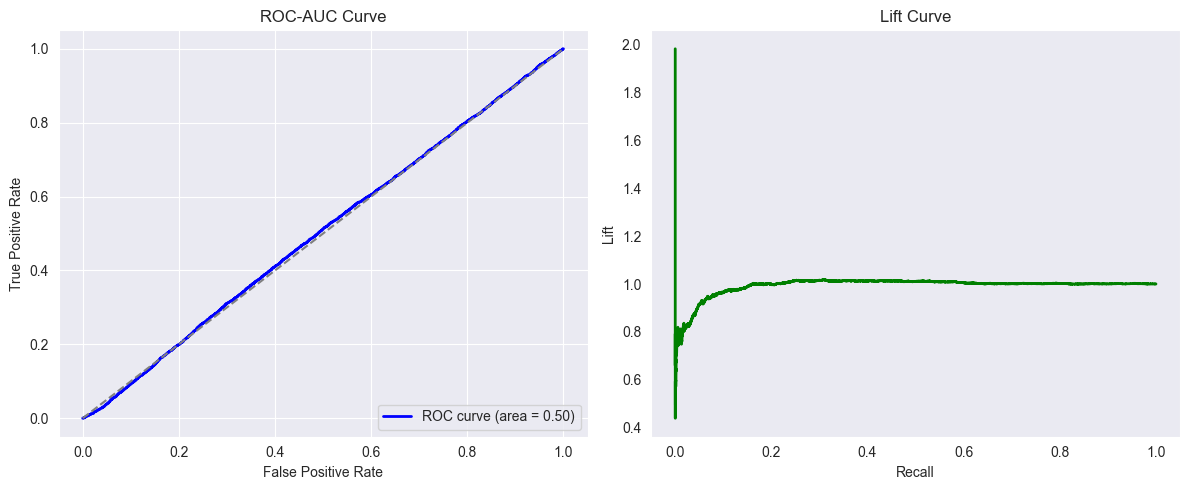

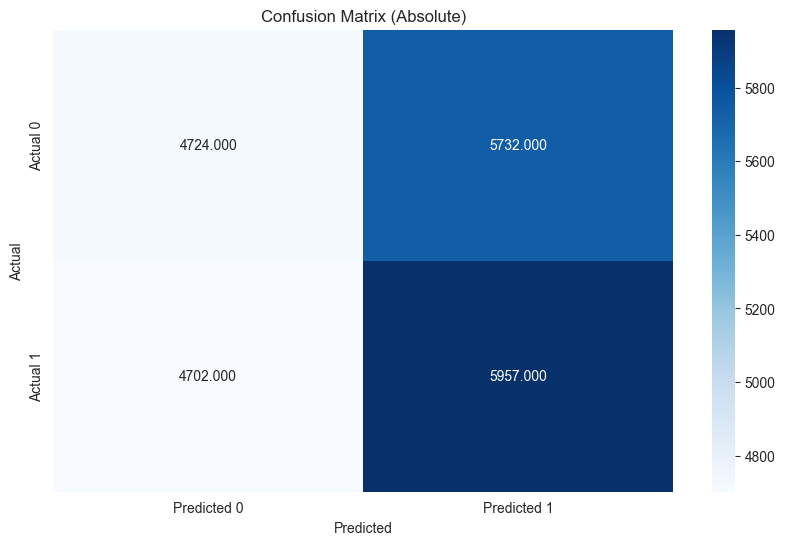

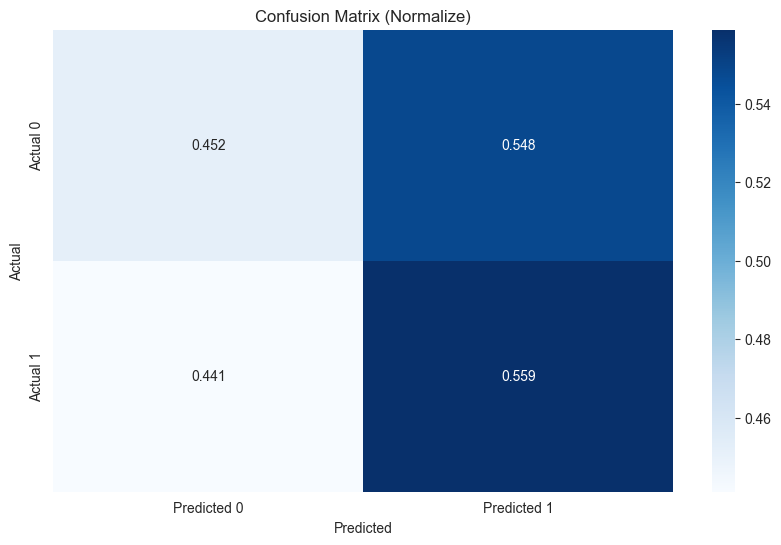

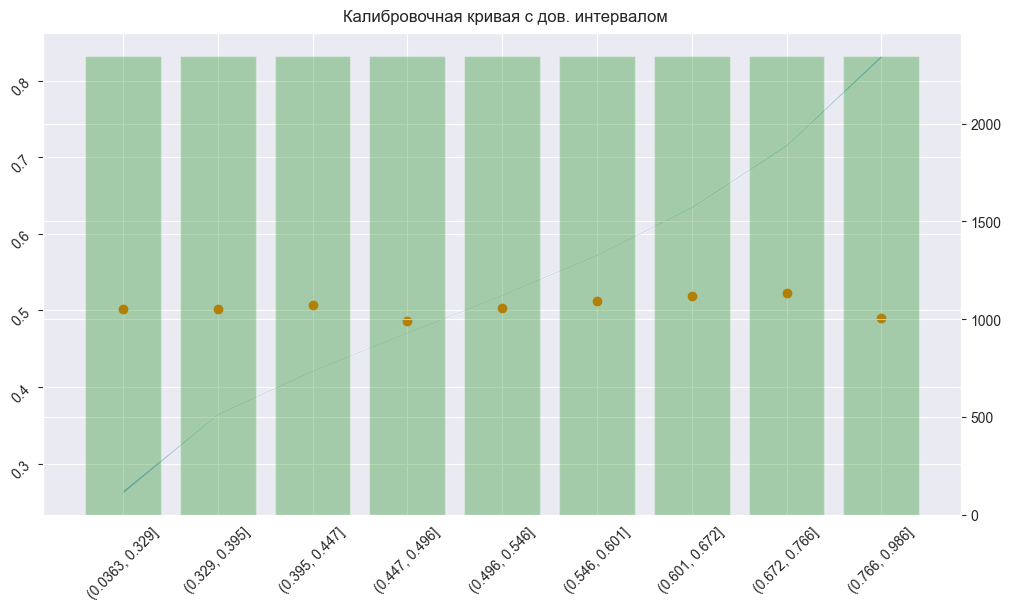

In [14]:
print("====================== ТЕСТ TIME ====================")
X_test, y_test = X_test_time, y_test_time
print(f'y_test shape {y_test.shape[0]}')
y_pred_proba = model.predict_proba(X_test)[:, 1] 
y_pred = [1  if x >= optimal_threshold else 0 for x in y_pred_proba]

plot_roc_lift(y_test, y_pred_proba)

get_metrics(X_test, y_test, model, optimal_threshold)

plot_confusion_matrix(y_test, y_pred)

plot_calibration(y_test, y_pred_proba)

====================== ТЕСТ SAMPLE ====================
y_test shape 8756

=== Classification Metrics ===
                       Value
Examples           8,756.000
Accuracy               0.561
Precision (Binary)     0.559
Recall (Binary)        0.568
F1 (Binary)            0.563
ROC AUC                0.590
Optimal F1-Score       0.666
Optimal Threshold      0.498
Precision (Macro)      0.563
Recall (Macro)         0.563
F1 (Macro)             0.563
Precision (Micro)      0.563
Recall (Micro)         0.563
F1 (Micro)             0.563


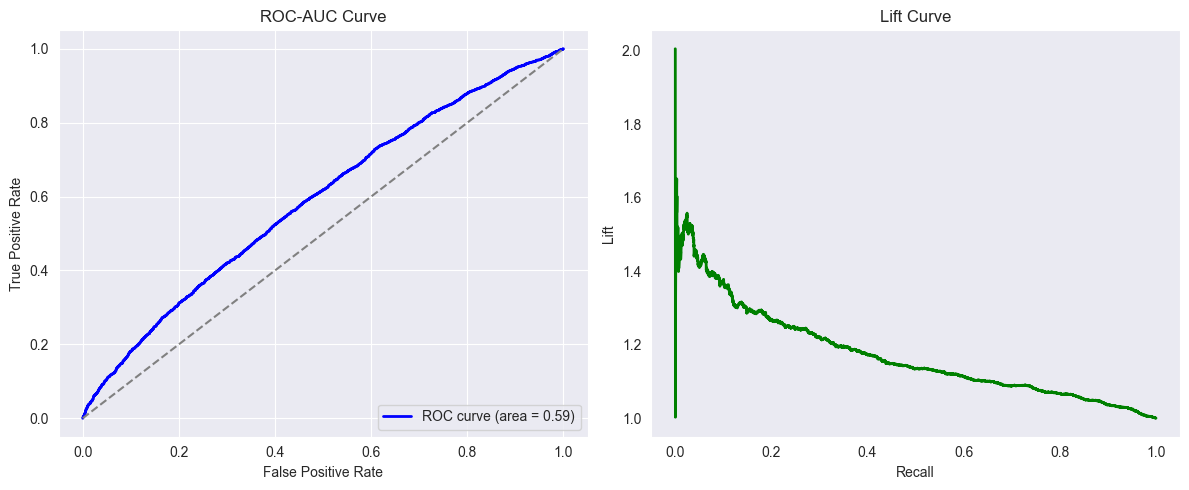

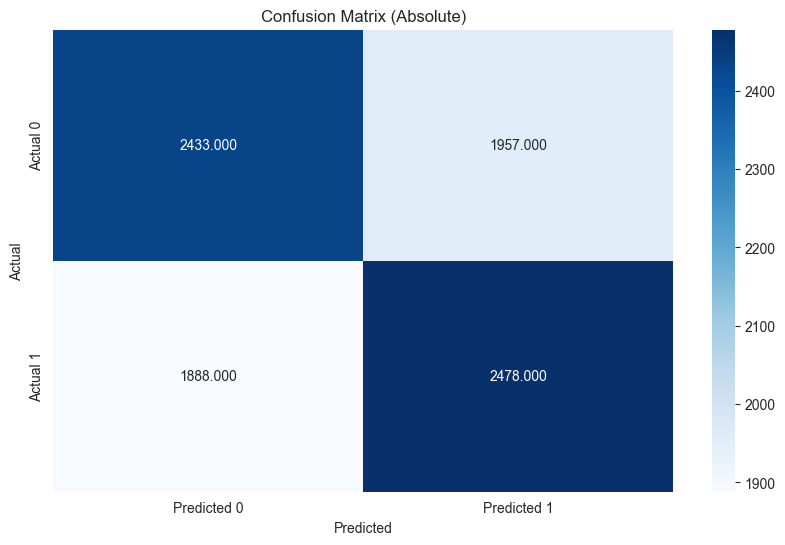

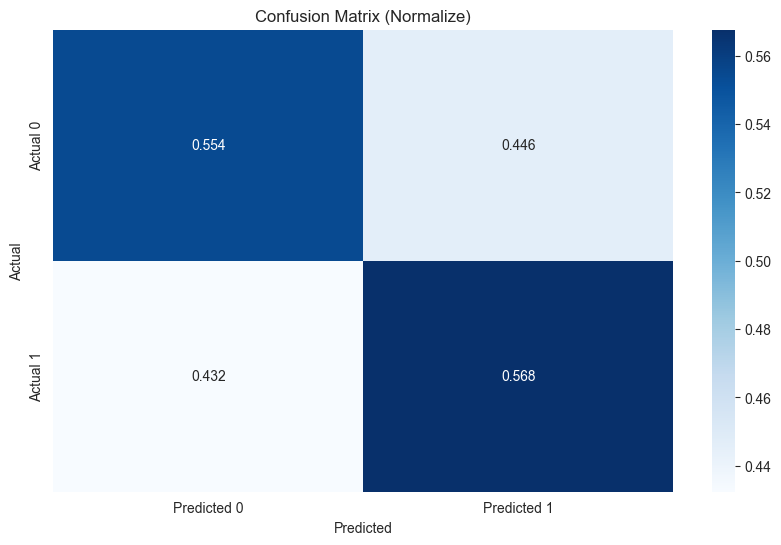

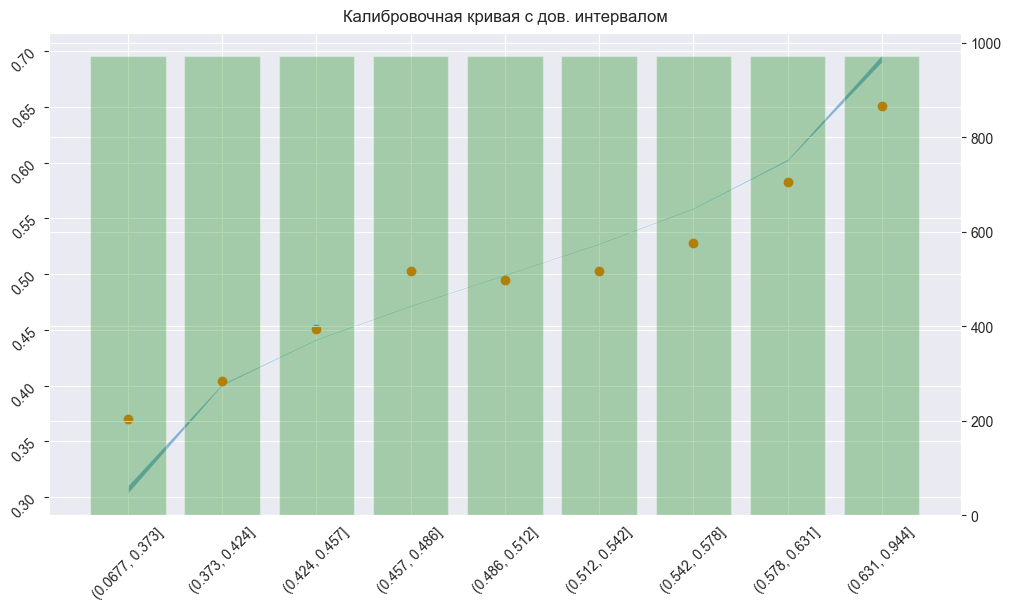

In [15]:
print("====================== ТЕСТ SAMPLE ====================")
X_test, y_test = X_test_sample, y_test_sample
print(f'y_test shape {y_test.shape[0]}')
y_pred_proba = model.predict_proba(X_test)[:, 1] 
y_pred = [1  if x >= optimal_threshold else 0 for x in y_pred_proba]

plot_roc_lift(y_test, y_pred_proba)

get_metrics(X_test, y_test, model, optimal_threshold)

plot_confusion_matrix(y_test, y_pred)

plot_calibration(y_test, y_pred_proba)
# display(pd.Series(y_pred_proba).describe(percentiles=[i for i in np.arange(0,1,0.05)]))
# plot_metrics(y_test, y_pred, y_pred_proba)
# plot_roc_lift(y_test, y_pred_proba) 

# plot_confusion_matrix(y_test, y_pred)
    

In [16]:
result = pd.DataFrame({'dataset':'train', 
                       'predict_proba': model.predict_proba(X_train)[:, 1] })  
result = pd.concat([result, pd.DataFrame({'dataset':'valid', 
                       'predict_proba': model.predict_proba(X_valid)[:, 1] })], axis=0)
result = pd.concat([result, pd.DataFrame({'dataset':'test_time', 
                       'predict_proba': model.predict_proba(X_test_time)[:, 1] })], axis=0)
result = pd.concat([result, pd.DataFrame({'dataset':'test_sample', 
                       'predict_proba': model.predict_proba(X_test_sample)[:, 1] })], axis=0)

In [17]:
# Разбиваем на бины
bins = np.linspace(0, 1, 21)  # 20 интервалов: [0.0, 0.05, ..., 1.0]
labels = [f"{bins[i]:.2f}-{bins[i+1]:.2f}" for i in range(len(bins)-1)]
result['bin'] = pd.cut(result['predict_proba'], bins=bins, labels=labels, include_lowest=True)

# Считаем доли и транспонируем
result = (
    result.groupby(['dataset', 'bin'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
    .T  # Транспонирование матрицы
)

result

dataset,test_sample,test_time,train,valid
bin,,,,
0.00-0.05,0.000,0.000,0.000,0.000
0.05-0.10,0.001,0.000,0.002,0.001
0.10-0.15,0.003,0.001,0.006,0.002
0.15-0.20,0.004,0.004,0.012,0.005
0.20-0.25,0.010,0.010,0.020,0.011
0.25-0.30,0.020,0.020,0.033,0.022
0.30-0.35,0.041,0.040,0.053,0.042
0.35-0.40,0.083,0.075,0.087,0.085
0.40-0.45,0.143,0.142,0.134,0.146
